# Preludio — De una cuenta a mano a la sensibilidad dinámica

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
# Encuentra la raíz tanto desde la carpeta del notebook como desde la raíz del libro.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'sa_mise' / '__init__.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from sa_mise import datos, modelos, expediente
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})

## 1. Iterar no es volver a empezar
Con r=2,8 y x inicial 0,2, calcula a mano el siguiente estado. Después usa ese resultado para calcular otro. La tabla muestra el proceso; todavía no buscamos caos.

In [2]:
r=2.8;x=.2;filas=[]
for paso in range(8):
    siguiente=r*x*(1-x)
    filas.append([paso,x,siguiente]);x=siguiente
display(pd.DataFrame(filas,columns=['paso','x_actual','x_siguiente']))

,paso,x_actual,x_siguiente
0,0,0.200000,0.448000
1,1,0.448000,0.692429
2,2,0.692429,0.596319
3,3,0.596319,0.674023
4,4,0.674023,0.615205
5,5,0.615205,0.662838
6,6,0.662838,0.625754
7,7,0.625754,0.655720


La primera actualización es 0,448. Cada fila recibe el resultado de la anterior. La no linealidad está en multiplicar x por 1−x. El estado es adimensional y el paso no corresponde a un año real.

## 2. Misma ecuación, distintos regímenes
Ahora guardamos toda la trayectoria en una función corta. Anticipa si aumentar r solo aumentará el nivel final. Dibujaremos la parte final para separar transitorio y comportamiento persistente.

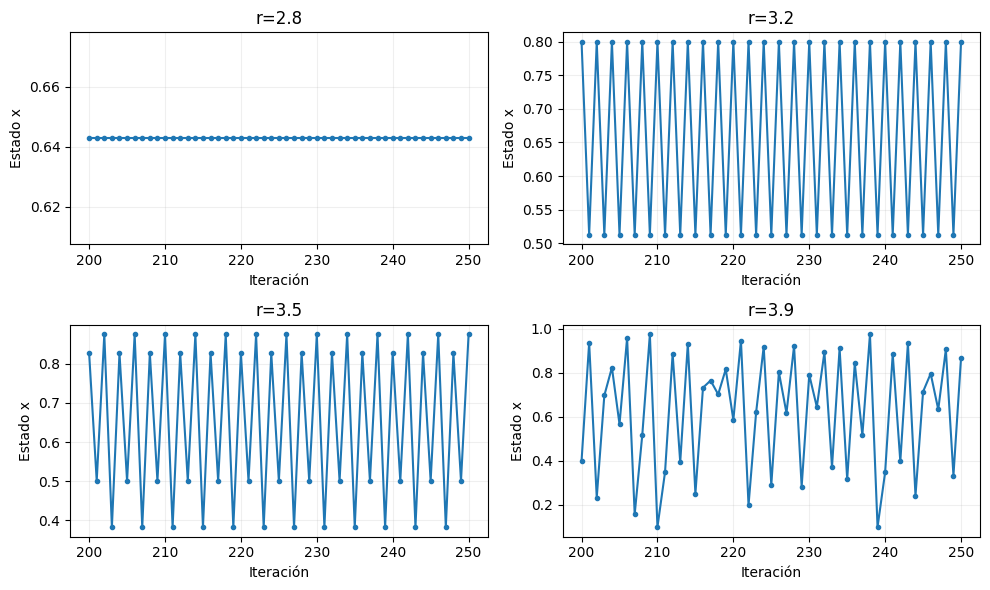

In [3]:
def logistica(r,x0=.2,n=250):
    xs=[x0]
    for _ in range(n):xs.append(r*xs[-1]*(1-xs[-1]))
    return np.array(xs)
fig,axs=plt.subplots(2,2,figsize=(10,6))
for ax,r in zip(axs.flat,[2.8,3.2,3.5,3.9]):
    xs=logistica(r);ax.plot(np.arange(200,251),xs[200:],'.-')
    ax.set(title=f'r={r}',xlabel='Iteración',ylabel='Estado x')
plt.tight_layout();plt.show()
assert abs(logistica(2.8)[-1]-(1-1/2.8))<1e-8

Con r=2,8 encontramos el punto fijo no nulo. Con otros valores aparecen ciclos o variaciones irregulares. El cambio no se reduce a «más r, más x». Una serie irregular no basta para demostrar caos; examinaremos también sensibilidad. El punto fijo calculado sirve como control del programa.

## 3. Una pequeña diferencia inicial
Compara dos estados iniciales separados por una millonésima. La escala logarítmica permite ver separaciones pequeñas. La distancia no puede crecer ilimitadamente porque ambas trayectorias permanecen acotadas.

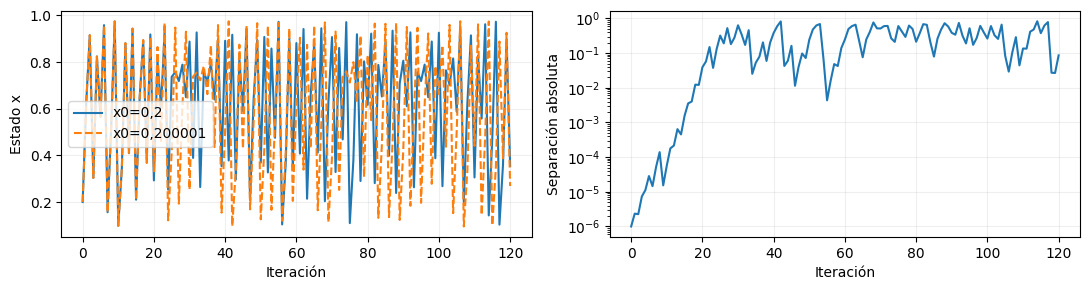

In [4]:
a=logistica(3.9,.2,120);b=logistica(3.9,.200001,120)
fig,axs=plt.subplots(1,2,figsize=(11,3))
axs[0].plot(a,label='x0=0,2');axs[0].plot(b,'--',label='x0=0,200001');axs[0].legend()
axs[0].set(xlabel='Iteración',ylabel='Estado x')
axs[1].semilogy(np.maximum(np.abs(a-b),1e-16));axs[1].set(xlabel='Iteración',ylabel='Separación absoluta')
plt.tight_layout();plt.show()

Las trayectorias pueden separarse aunque las reglas sean idénticas. Cambia r a 2,8 y repite: la misma perturbación puede amortiguarse. La comparación identifica sensibilidad dependiente del régimen. No hemos añadido ruido ni estimado un horizonte para precios eléctricos.

## 4. Bifurcaciones: observar muchos parámetros
Para cada r descartamos mil iteraciones y dibujamos las cien siguientes. Cada columna es un experimento independiente. Repite un intervalo estrecho para explorar una ventana periódica.

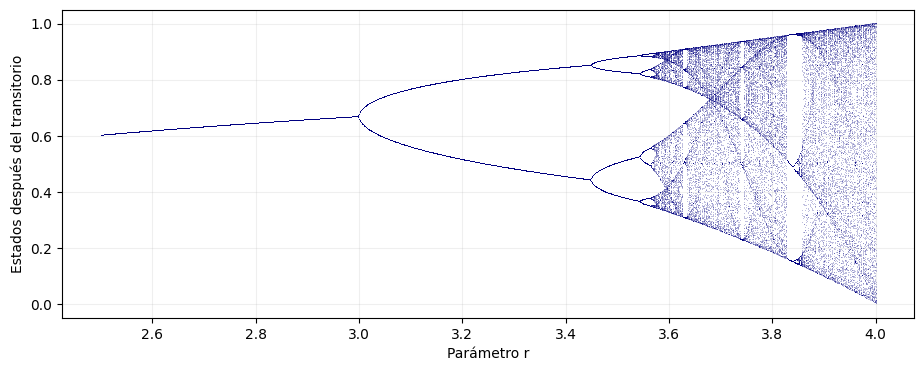

In [5]:
rs=np.linspace(2.5,4,1200);x=np.full_like(rs,.2345)
for _ in range(1000):x=rs*x*(1-x)
plt.figure(figsize=(11,4))
for _ in range(100):
    x=rs*x*(1-x);plt.plot(rs,x,',',color='navy',alpha=.25)
plt.xlabel('Parámetro r');plt.ylabel('Estados después del transitorio');plt.show()

Las ramas corresponden a estados visitados después del transitorio, no a barras de incertidumbre estadística. Las ventanas recuerdan que una etiqueta global «r alto = caos» es demasiado simple. La resolución finita del gráfico tampoco demuestra autosimilitud exacta.

## 5. Lorenz: el estado tiene tres coordenadas
Estas son las ecuaciones del modelo reducido, con parámetros clásicos del experimento. El integrador aproxima trayectorias continuas; sus tolerancias son parte del cálculo. Las variables no son series observadas del clima colombiano.

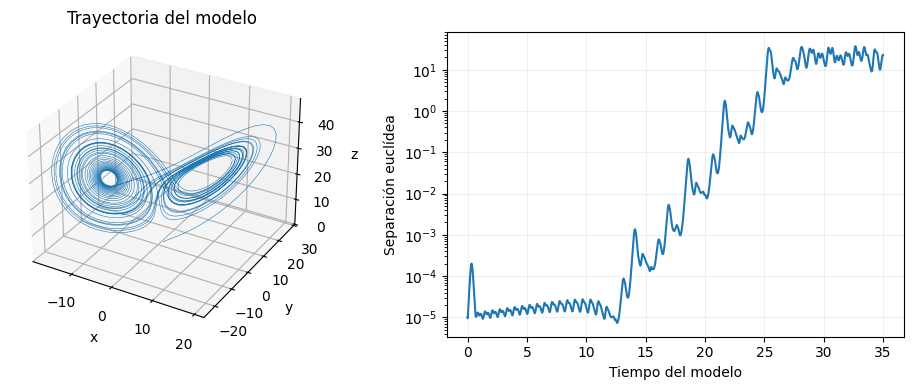

In [6]:
from scipy.integrate import solve_ivp
def lorenz(t,y):
    x,yv,z=y
    return [10*(yv-x),x*(28-z)-yv,x*yv-(8/3)*z]
t=np.linspace(0,35,3501)
l1=solve_ivp(lorenz,(0,35),[1,1,1],t_eval=t,rtol=1e-10,atol=1e-12)
l2=solve_ivp(lorenz,(0,35),[1.00001,1,1],t_eval=t,rtol=1e-10,atol=1e-12)
assert l1.success and l2.success
fig=plt.figure(figsize=(10,4));ax=fig.add_subplot(121,projection='3d')
ax.plot(*l1.y,lw=.4);ax.set(xlabel='x',ylabel='y',zlabel='z',title='Trayectoria del modelo')
ax2=fig.add_subplot(122);ax2.semilogy(t,np.linalg.norm(l1.y-l2.y,axis=0))
ax2.set(xlabel='Tiempo del modelo',ylabel='Separación euclídea');plt.tight_layout();plt.show()

La figura tridimensional muestra una estructura global mientras la separación examina precisión de trayectoria. No son el mismo objeto. Repite un horizonte corto con tolerancias más estrictas antes de atribuir pequeñas diferencias al mecanismo físico. Este laboratorio demuestra comportamientos de las ecuaciones; no identifica caos en el SIN.

**Transferencia:** escribe una pregunta energética para la que importen secuencia, memoria o sensibilidad. Señala qué mediciones necesitarías y qué análisis convencional usarías como referencia. No propongas usar Lorenz como sustituto de un modelo hidrológico.